In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [9]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [10]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [11]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [12]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [13]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [14]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [15]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [16]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [17]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [18]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [19]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [21]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [22]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [24]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [25]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [26]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [27]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

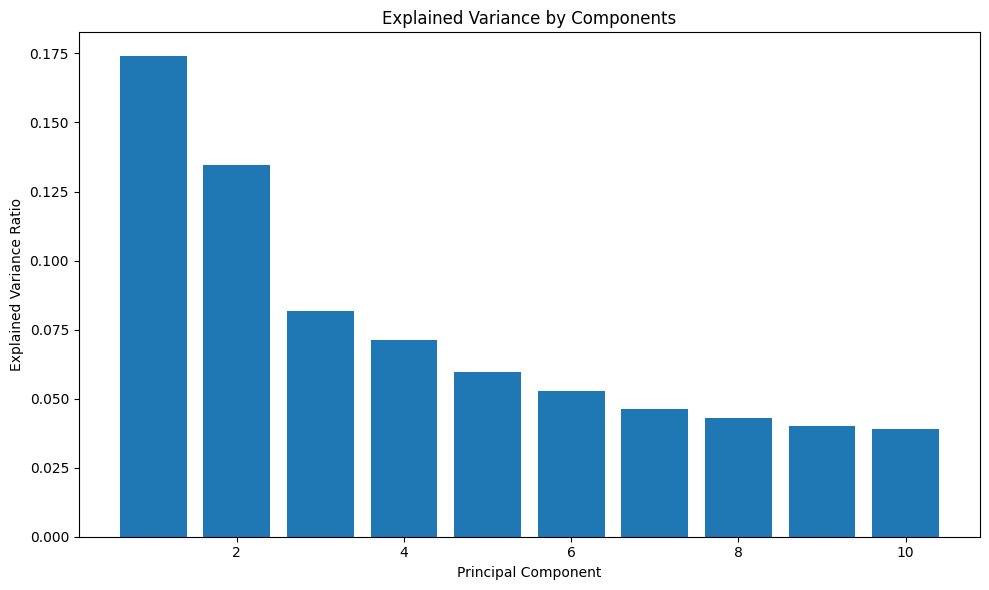

In [28]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [29]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [30]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

In [31]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [32]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

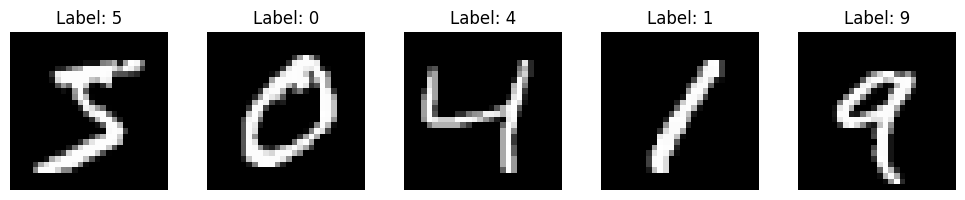

In [33]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [77]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

In [78]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

0.0 1.0


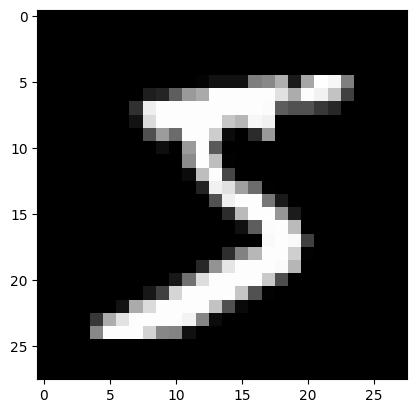

In [79]:
print(X_train_img.min(), X_train_img.max())
plt.imshow(X_train_img[0].reshape(28,28), cmap='gray')
plt.show()

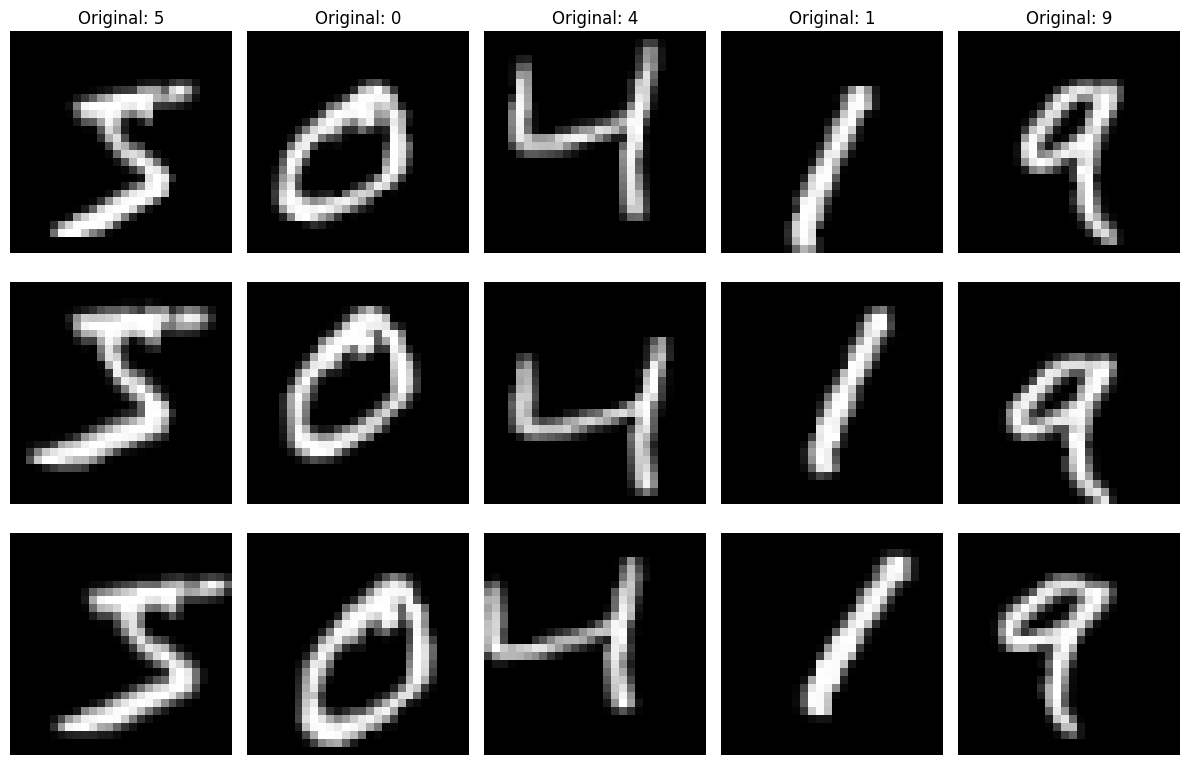

In [80]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [38]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.1)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [39]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

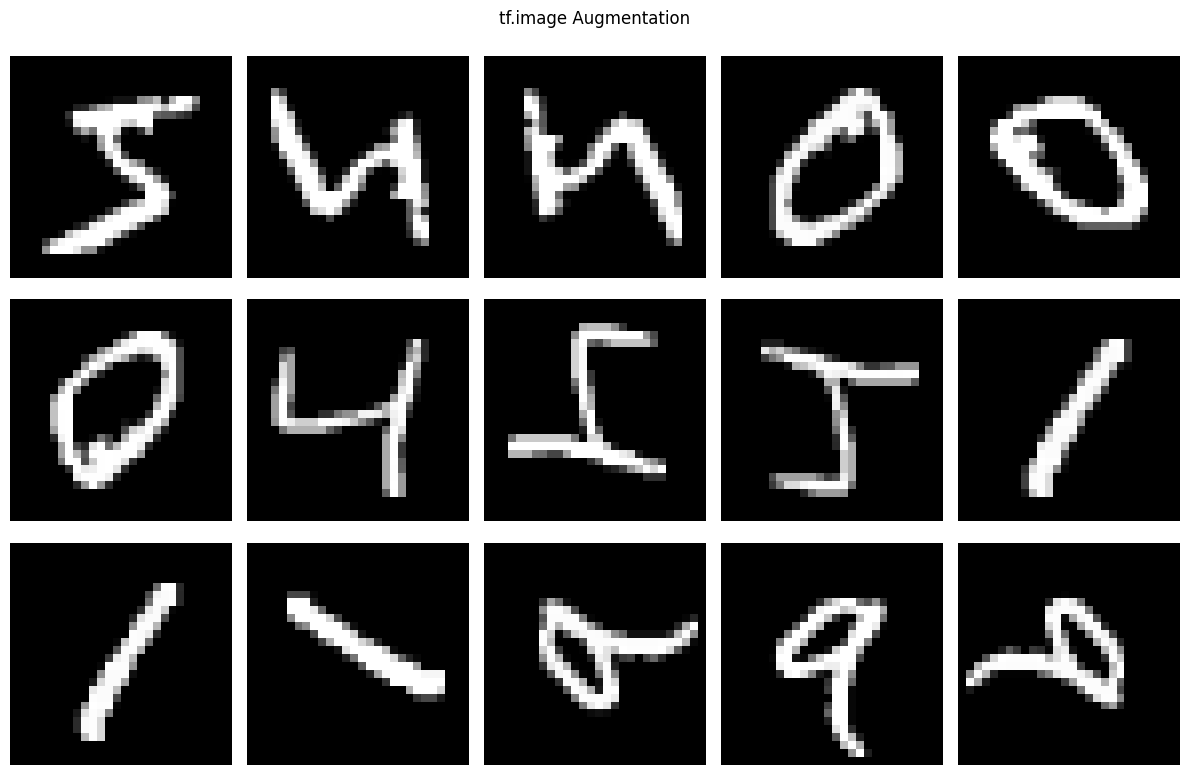

In [40]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [41]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

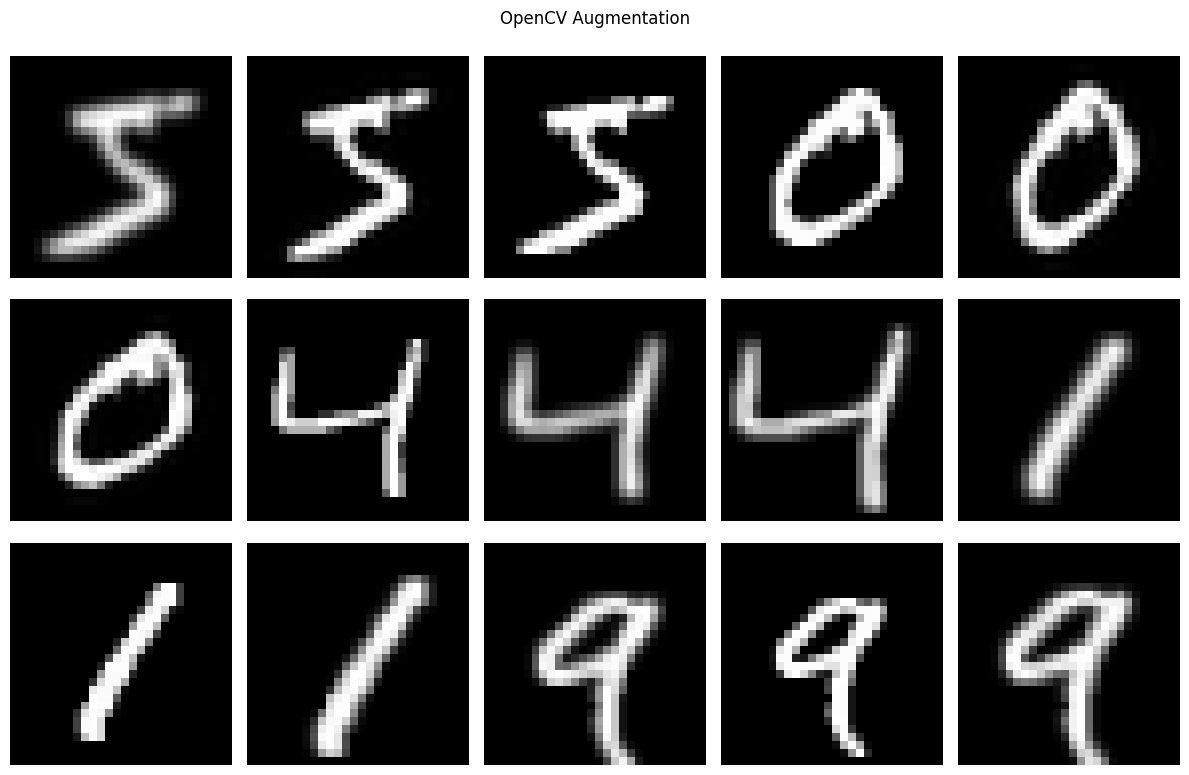

In [42]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

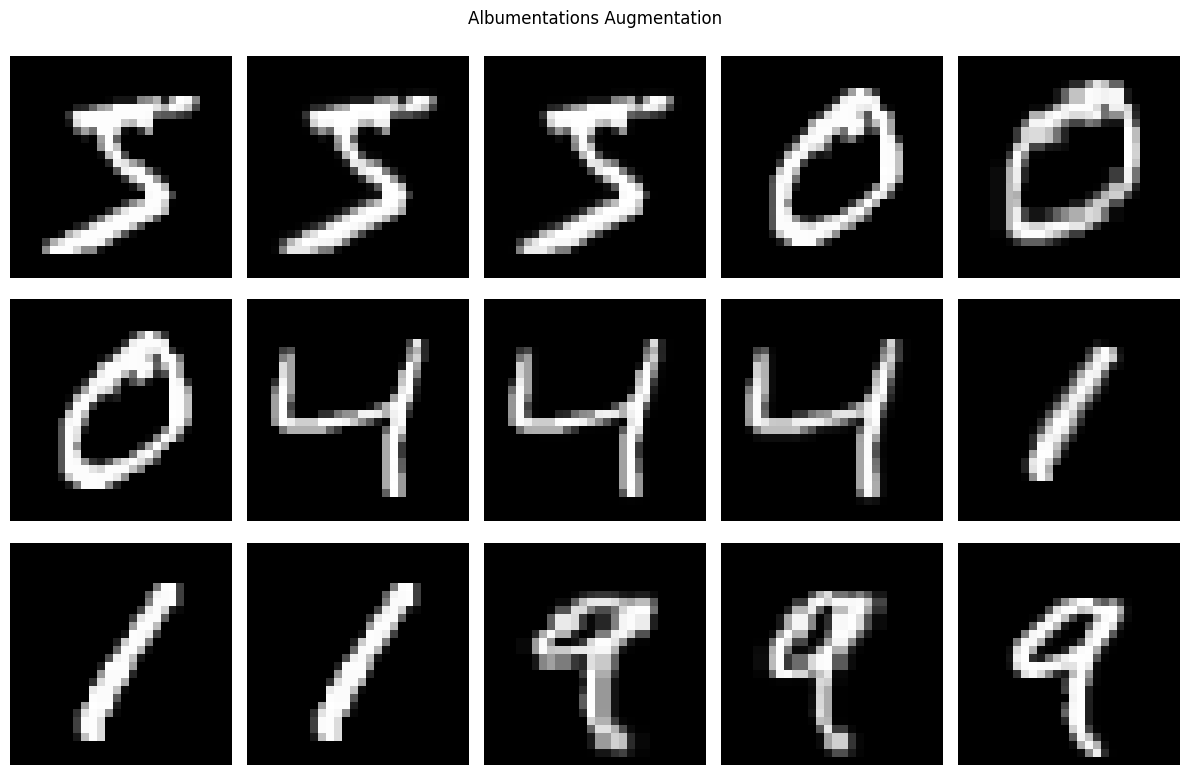

In [43]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [44]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [45]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [46]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [47]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: This is product, great a I love it!
Word Deletion: This is a great product, I it!
Word Insertion: This is somewhat a great product, I love it!
Original: The service was terrible and I'm disappointed.
Word Swap: The service I'm terrible and was disappointed.
Word Deletion: The service was terrible and disappointed.
Word Insertion: The service was terrible and extremely I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: I'm I sure how not feel about this experience.
Word Deletion: I'm not sure I feel about this experience.
Word Insertion: I'm not really sure how I feel about this experience.
Original: The food was delicious and the staff was friendly.
Word Swap: The and was delicious food the staff was friendly.
Word Deletion: The food delicious and the staff was friendly.
Word Insertion: The food was quite delicious and the staff was friendly.
Original: This movi

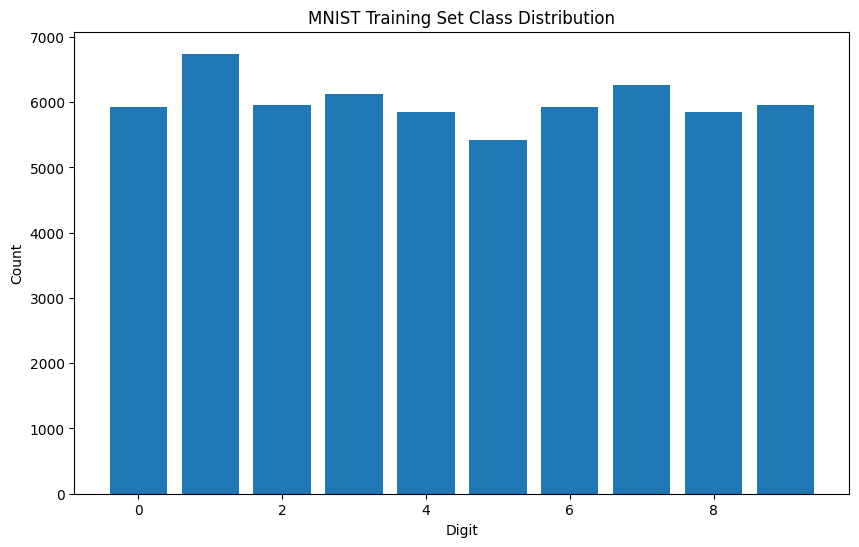

In [48]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [49]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [50]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [51]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [52]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [53]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [54]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [55]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [56]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [57]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

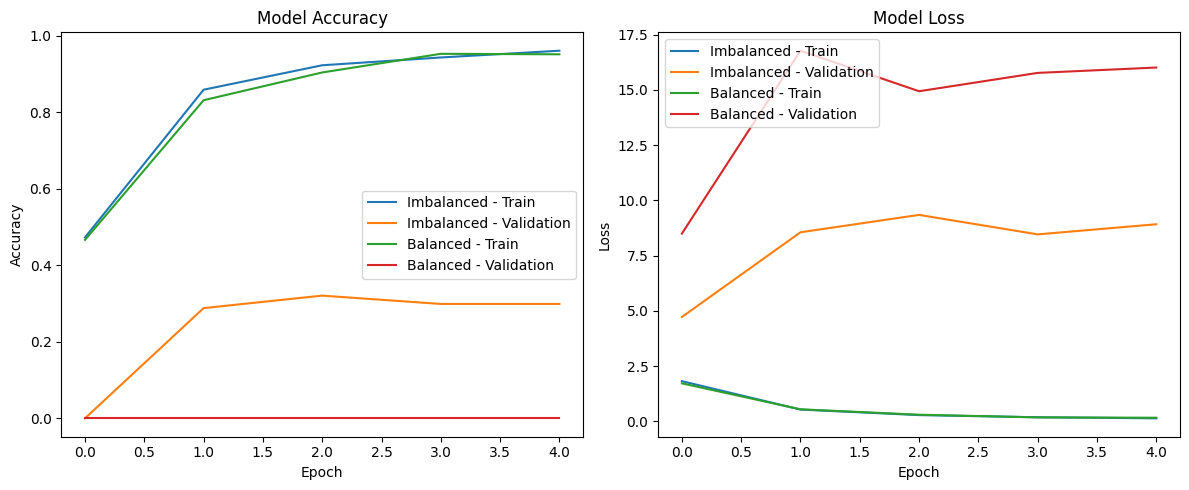

In [58]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Excercise

In [59]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# Load the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# Display the first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Replace missing Cabin values with 'Unknown'
df['Cabin'].fillna('Unknown', inplace=True)

# Check remaining missing values
print(df[['Age', 'Embarked', 'Cabin']].isnull().sum())

Age         0
Embarked    0
Cabin       0
dtype: int64


In [61]:
# 3.1 Extract Title from Name
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
               'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# 3.3 Family Size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, 100],
    labels=['Child', 'Teenager', 'Adult', 'Elderly'],
    include_lowest=True
)

# Experiment: Using 5 quantiles instead of 4
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

# 3.6 Deck from Cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'Unknown')

rare_decks = ['T', 'G', 'F']
df['Deck'] = df['Deck'].replace(rare_decks, 'Other')

# Preview
df[['Title', 'FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBin', 'FareBin', 'Deck']].head()


,Title,FamilySize,IsAlone,FarePerPerson,AgeBin,FareBin,Deck
0,Mr,2,0,3.62500,Adult,Very Low,Unknown
1,Mrs,2,0,35.64165,Adult,Very High,C
2,Miss,1,1,7.92500,Adult,Low,Unknown
3,Mrs,2,0,26.55000,Adult,Very High,C
4,Mr,1,1,8.05000,Adult,Low,Unknown


In [62]:
# 3.1 Extract Title from Name
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# 3.3 Family Size and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3.4 Fare Per Person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, float('inf')],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)

# Experiment: changed quantiles from 4 to 5
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

# 3.6 Deck from Cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'Unknown')

rare_decks = ['T', 'G', 'F']
df['Deck'] = df['Deck'].replace(rare_decks, 'Other')

# Display new features
df[['Title', 'FamilySize', 'IsAlone', 'FarePerPerson',
    'AgeBin', 'FareBin', 'Deck']].head()

,Title,FamilySize,IsAlone,FarePerPerson,AgeBin,FareBin,Deck
0,Mr,2,0,3.62500,Adult,Very Low,Unknown
1,Mrs,2,0,35.64165,Adult,Very High,C
2,Miss,1,1,7.92500,Adult,Low,Unknown
3,Mrs,2,0,26.55000,Adult,Very High,C
4,Mr,1,1,8.05000,Adult,Low,Unknown


In [63]:
# 4. Encoding and Scaling

# 4.1 One-hot encode categorical features
categorical = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']

# Experiment: keep all dummy variables
df_encoded = pd.get_dummies(df[categorical], drop_first=False)

# 4.2 Combine with numerical features
numerical = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']

X = pd.concat([df[numerical], df_encoded], axis=1)
y = df['Survived']

# 4.3 Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()
scaler_rbv = RobustScaler()

X_std = scaler_std.fit_transform(X)
X_mm = scaler_mm.fit_transform(X)
X_rb = scaler_rbv.fit_transform(X)

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 35)
y shape: (891,)


In [64]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Experiment: Use k=12 instead of k=15
selector = SelectKBest(score_func=f_classif, k=12)

X_sel = selector.fit_transform(X_std, y)

top_feats = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).nlargest(12, 'Score')

print("Top Selected Features:")
print(top_feats)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sel,
    y,
    test_size=0.25,
    random_state=42
)

# Experiment: Increase number of trees
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Top Selected Features:
              Feature       Score
15           Title_Mr  383.945495
8          Sex_female  372.405724
9            Sex_male  372.405724
16          Title_Mrs  117.749079
7              Pclass  115.031272
14         Title_Miss  112.860827
34       Deck_Unknown   99.253142
27  FareBin_Very High   66.287877
3                Fare   63.030764
6       FarePerPerson   45.910184
5             IsAlone   38.353651
24        FareBin_Low   33.918795

Accuracy: 0.8161434977578476

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       134
           1       0.78      0.75      0.77        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



Polynomial Feature Names:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2' 'Age^3' 'Age^2 Fare'
 'Age Fare^2' 'Fare^3']


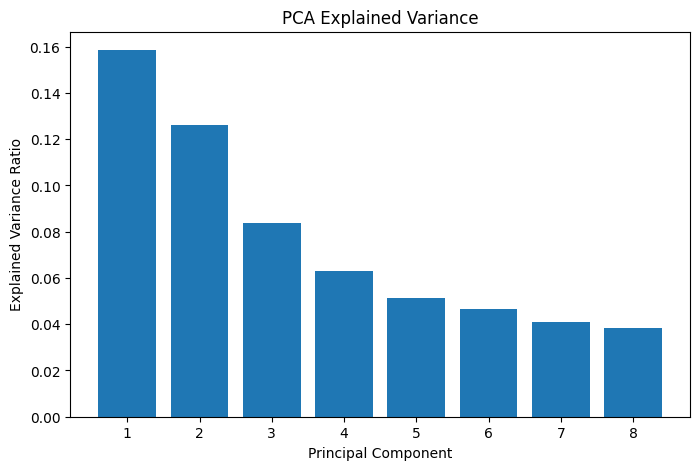

Cumulative Explained Variance:
[0.1585631  0.28466042 0.36828414 0.43142345 0.48266111 0.52911252
 0.57000272 0.60830906]


In [65]:
# 6. Advanced Feature Engineering

# 6.1 Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

# Experiment: degree=3 instead of 2
poly = PolynomialFeatures(degree=3, include_bias=False)

poly_data = poly.fit_transform(df[['Age', 'Fare']].fillna(0))

print("Polynomial Feature Names:")
print(poly.get_feature_names_out(['Age', 'Fare']))

# 6.2 PCA for Dimensionality Reduction
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Experiment: use 8 principal components instead of 10
pca = PCA(n_components=8)

X_pca = pca.fit_transform(X_std)

# Plot Explained Variance Ratio
plt.figure(figsize=(8,5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

# Print cumulative explained variance
print("Cumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))


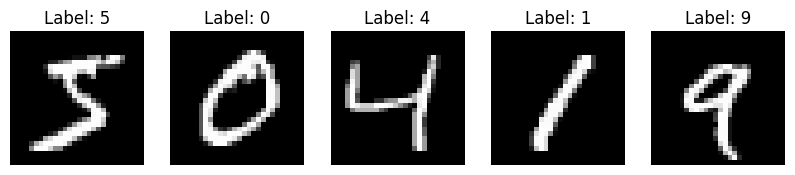

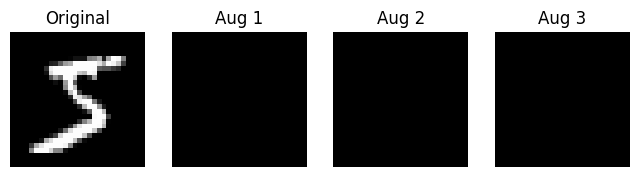

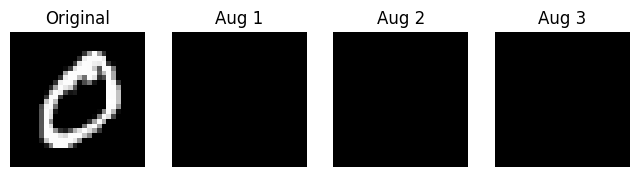

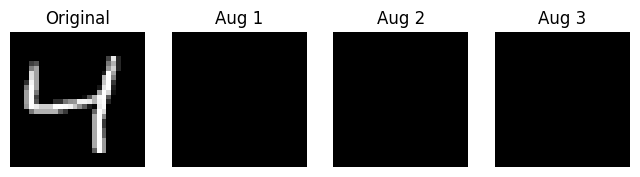

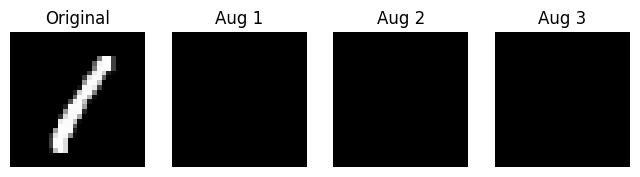

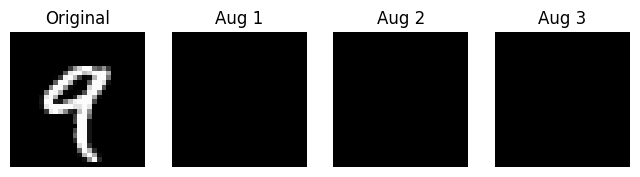

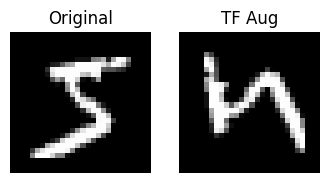

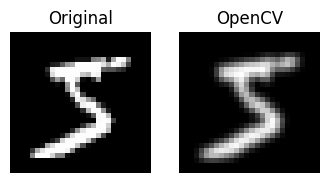

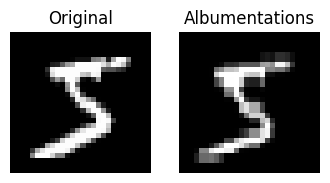

In [66]:
# 7. Image Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from scipy import ndimage
import numpy as np
import random
import albumentations as A

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize and reshape
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Display 5 sample images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# 7.1 ImageDataGenerator (Experimented Parameters)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate and plot 3 augmentations for first 5 images
for i in range(5):
    image = X_train[i].reshape((1,28,28,1))

    fig, axes = plt.subplots(1,4, figsize=(8,2))

    axes[0].imshow(image[0].reshape(28,28), cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    aug_iter = datagen.flow(image, batch_size=1)

    for j in range(3):
        batch = next(aug_iter)
        axes[j+1].imshow(batch[0].reshape(28,28), cmap='gray')
        axes[j+1].set_title(f"Aug {j+1}")
        axes[j+1].axis('off')

    plt.show()

# 7.2 TensorFlow Image Augmentations

def tf_augment(image):
    image = tf.image.rot90(image)
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image

sample_tf = tf_augment(X_train[0])

plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_tf.numpy().reshape(28,28), cmap='gray')
plt.title("TF Aug")
plt.axis("off")
plt.show()

# 7.3 OpenCV Augmentations

def opencv_augment(image):
    img = image.squeeze()

    choice = random.choice(["rotate", "blur", "zoom"])

    if choice == "rotate":
        angle = random.randint(-20,20)
        img = ndimage.rotate(img, angle, reshape=False)

    elif choice == "blur":
        img = cv2.GaussianBlur(img, (3,3), 0)

    elif choice == "zoom":
        scale = 1.2
        h, w = img.shape
        resized = cv2.resize(img, None, fx=scale, fy=scale)
        startx = (resized.shape[1]-w)//2
        starty = (resized.shape[0]-h)//2
        img = resized[starty:starty+h, startx:startx+w]

    return img

opencv_img = opencv_augment(X_train[0])

plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opencv_img, cmap='gray')
plt.title("OpenCV")
plt.axis("off")
plt.show()

# 7.4 Albumentations Pipeline

albumentations_pipeline = A.Compose([
    A.RandomBrightnessContrast(p=0.8),
    A.ElasticTransform(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5)
])

sample = (X_train[0].reshape(28,28) * 255).astype(np.uint8)
augmented = albumentations_pipeline(image=sample)["image"]

plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented, cmap='gray')
plt.title("Albumentations")
plt.axis("off")
plt.show()

In [67]:
import random

# Sample sentences provided
texts = texts = [
    "Machine learning is fun",
    "Python is easy to learn",
    "Data preprocessing improves model performance"
]

# Swap two random words
def swap_words(text):
    words = text.split()
    if len(words) > 1:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)

# Delete one random word
def delete_random_word(text):
    words = text.split()
    if len(words) > 1:
        words.pop(random.randint(0, len(words) - 1))
    return " ".join(words)

# Insert a random existing word
def insert_random_word(text):
    words = text.split()
    word = random.choice(words)
    pos = random.randint(0, len(words))
    words.insert(pos, word)
    return " ".join(words)

# Print augmented variants
for text in texts:
    print("Original:", text)
    print("Swap:   ", swap_words(text))
    print("Delete: ", delete_random_word(text))
    print("Insert: ", insert_random_word(text))
    print("-" * 40)

Original: Machine learning is fun
Swap:    learning Machine is fun
Delete:  Machine learning is
Insert:  Machine learning is is fun
----------------------------------------
Original: Python is easy to learn
Swap:    learn is easy to Python
Delete:  Python easy to learn
Insert:  Python Python is easy to learn
----------------------------------------
Original: Data preprocessing improves model performance
Swap:    Data preprocessing performance model improves
Delete:  Data preprocessing improves performance
Insert:  Data preprocessing improves model performance performance
----------------------------------------


In [68]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Compute class distribution
unique, counts = np.unique(y_train_img, return_counts=True)
print("Class Distribution:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")

# ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Function to augment minority class
def augment_minority_class(X, y, target_class, num_samples):
    indices = np.where(y == target_class)[0]

    X_target = X[indices]
    y_target = y[indices]

    augmented_images = []
    augmented_labels = []

    generator = datagen.flow(X_target, y_target, batch_size=1)

    while len(augmented_images) < num_samples:
        img, label = next(generator)
        augmented_images.append(img[0])
        augmented_labels.append(label[0])

    X_balanced = np.concatenate([X, np.array(augmented_images)], axis=0)
    y_balanced = np.concatenate([y, np.array(augmented_labels)], axis=0)

    return X_balanced, y_balanced

# Example
X_balanced, y_balanced = augment_minority_class(
    X_train_img,
    y_train_img,
    target_class=0,
    num_samples=100
)

print("Balanced X shape:", X_balanced.shape)
print("Balanced y shape:", y_balanced.shape)


Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


MemoryError: Unable to allocate 359. MiB for an array with shape (60100, 28, 28, 1) and data type float64

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6522 - loss: 1.4124 - val_accuracy: 0.7165 - val_loss: 1.0492
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8522 - loss: 0.4875 - val_accuracy: 0.8341 - val_loss: 0.5490
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9228 - loss: 0.3183 - val_accuracy: 0.8312 - val_loss: 0.5827
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9326 - loss: 0.2314 - val_accuracy: 0.8374 - val_loss: 0.5660
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9554 - loss: 0.1678 - val_accuracy: 0.8525 - val_loss: 0.5507
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6380 - loss: 1.4837 - val_accuracy: 0.7808 - val_loss: 0.7732
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8320 - loss: 0.5231 - val_accuracy: 0.8374 - val_loss: 0.5223
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8930 - loss: 0.3527 - val_accuracy: 0.8644 - val_loss:

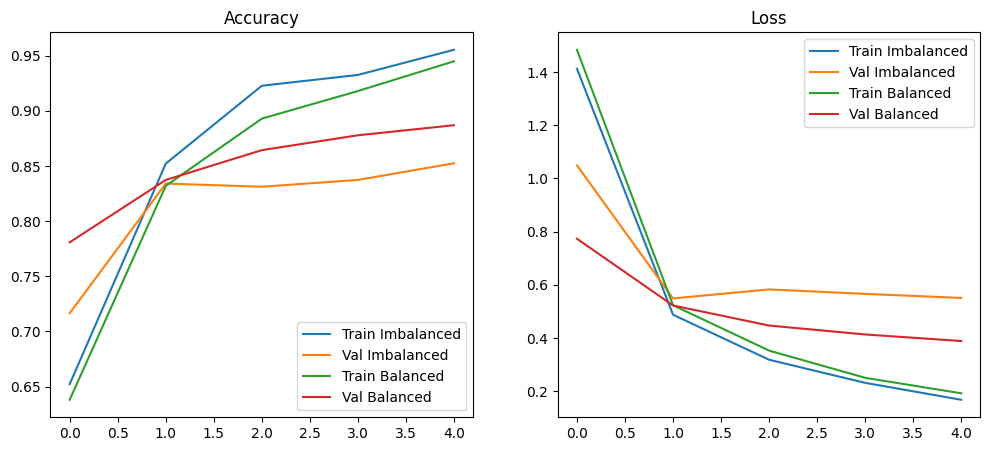

In [ ]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Simple CNN
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create an imbalanced dataset
X_imb = []
y_imb = []

for cls in range(10):
    idx = np.where(y_train == cls)[0][:100]

    # Reduce samples of class 8
    if cls == 8:
        idx = idx[:20]

    X_imb.append(X_train[idx])
    y_imb.append(y_train[idx])

X_imb = np.concatenate(X_imb)
y_imb = np.concatenate(y_imb)

# Train on imbalanced data
model1 = create_model()

history1 = model1.fit(
    X_imb,
    y_imb,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

# Balance class 8 using previous augmentation function
X_bal, y_bal = augment_minority_class(
    X_imb,
    y_imb,
    target_class=8,
    num_samples=80
)

# Train on balanced data
model2 = create_model()

history2 = model2.fit(
    X_bal,
    y_bal,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='Train Imbalanced')
plt.plot(history1.history['val_accuracy'], label='Val Imbalanced')
plt.plot(history2.history['accuracy'], label='Train Balanced')
plt.plot(history2.history['val_accuracy'], label='Val Balanced')
plt.title('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history1.history['loss'], label='Train Imbalanced')
plt.plot(history1.history['val_loss'], label='Val Imbalanced')
plt.plot(history2.history['loss'], label='Train Balanced')
plt.plot(history2.history['val_loss'], label='Val Balanced')
plt.title('Loss')
plt.legend()

plt.show()


**Experiment: feel free to tweak parameters (e.g., k in SelectKBest, PCA components, augmentation ranges) to see their impact.**